# Phase 7 — Regularization Experiments (Ridge · Lasso · ElasticNet)

Tunes `alpha` (and `l1_ratio` for ElasticNet) with **5-fold CV on the 70% train set only**. Every candidate is
`TransformedTargetRegressor(Pipeline([StandardScaler, model]), log1p, expm1)`, so the scaler is **re-fit in every
fold** and all scores are in **₹**. The selection metric is **CV RMSE (₹)**; MAE, R² and RMSLE are tracked alongside.

Reported: under/overfitting (train vs CV error along alpha), coefficient shrinkage, the number of coefficients
driven to 0, and validation RMSE/MAE/R² of the tuned models vs the Phase-6 defaults. Validation is used only to
**compare**, never to choose alpha. The test set is untouched (`EVALUATE_TEST = False`).

The notebook does **no data cleaning**. Upload `prepared_data.joblib` into the Colab working directory, then *Run all*.

In [1]:
# No extra packages needed: scikit-learn, pandas, numpy, matplotlib and joblib are preinstalled in Colab.

In [2]:
import os, json, time, hashlib, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
EVALUATE_TEST = False                      # stays False until Phase 9
EXPECTED_REFERENCE_ID = "70560d1bd70af7cd" # from phase5_prepare_data.ipynb
CV_FOLDS = 5
os.makedirs("outputs", exist_ok=True)

In [3]:
d = joblib.load("prepared_data.joblib")       # numpy arrays + builtins only → loads under any pandas version
if not str(d.get("storage_format", "")).startswith("numpy-v1") or not isinstance(d["X_train"], np.ndarray):
    raise RuntimeError("BUNDLE / NOTEBOOK VERSION MISMATCH — STOP. This notebook expects the numpy-format bundle "
                       "(storage_format 'numpy-v1') written by the current phase5_prepare_data.ipynb. "
                       "Re-upload BOTH the latest prepared_data.joblib and the latest copy of this notebook.")
feature_names = list(d["feature_names"])

def frames_from_bundle(d):
    # Rebuild DataFrames/Series: float64 X, int64 y in rupees, original row ids as index (identical to Phase 5)
    out = {}
    for s in ("train", "val", "test"):
        idx = pd.Index(d[f"index_{s}"], dtype="int64")
        out[f"X_{s}"] = pd.DataFrame(d[f"X_{s}"], columns=feature_names, index=idx)
        out[f"y_{s}"] = pd.Series(d[f"y_{s}"], index=idx, name="Rent")
    return out

f = frames_from_bundle(d)
X_train, X_val, X_test = f["X_train"], f["X_val"], f["X_test"]
y_train, y_val, y_test = f["y_train"], f["y_val"], f["y_test"]
print("Loaded:", X_train.shape, X_val.shape, X_test.shape, "| target_transform:", d["target_transform"])

Loaded: (3313, 34) (711, 34) (711, 34) | target_transform: log1p


In [4]:
def _h(b):
    return hashlib.sha256(b).hexdigest()[:16]

def compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names):
    splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
    ref = {"n_rows": {k: int(len(x)) for k, (x, _) in splits.items()},
           "n_features": len(feature_names),
           "feature_names_hash": _h("|".join(feature_names).encode()),
           "index_hash_sorted": {k: _h(np.sort(x.index.to_numpy("int64")).tobytes()) for k, (x, _) in splits.items()},
           "index_hash_ordered": {k: _h(x.index.to_numpy("int64").tobytes()) for k, (x, _) in splits.items()},
           "target_hash": {k: _h(y.to_numpy("int64").tobytes()) for k, (_, y) in splits.items()}}
    ref["reference_id"] = _h(json.dumps(ref, sort_keys=True).encode())
    content = {k: _h(np.ascontiguousarray(x.to_numpy("float64")).tobytes()) for k, (x, _) in splits.items()}
    return {"reference": ref, "content": content}

fp = compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names)
problems = []
if fp["reference"]["reference_id"] != EXPECTED_REFERENCE_ID:
    problems.append(f"reference_id {fp['reference']['reference_id']} != expected {EXPECTED_REFERENCE_ID}")
if fp["reference"] != d["fingerprint"]["reference"]:
    problems.append("reference fingerprint differs from the bundle's record")
if fp["content"] != d["fingerprint"]["content"]:
    problems.append("X content hash differs from the bundle's record")
if list(X_train.columns) != feature_names or list(X_val.columns) != feature_names or list(X_test.columns) != feature_names:
    problems.append("column order != feature_names")
if d["target_transform"] not in ("log1p", "none"):
    problems.append(f"unknown target_transform {d['target_transform']!r}")
if problems:
    raise RuntimeError("FINGERPRINT MISMATCH — STOP. Do not train.\n  " + "\n  ".join(problems))
print(f"Dataset:  Rows: {len(X_train) + len(X_val) + len(X_test)}  Features: {len(feature_names)}   Fingerprint: OK ({EXPECTED_REFERENCE_ID})")

Dataset:  Rows: 4735  Features: 34   Fingerprint: OK (70560d1bd70af7cd)


## 1. Shared CV set-up (train only)

In [5]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rmse = lambda a, p: float(np.sqrt(mean_squared_error(a, p)))
rmsle = lambda a, p: float(np.sqrt(mean_squared_error(np.log1p(a), np.log1p(np.clip(p, 0, None)))))
SCORING = {"rmse": make_scorer(rmse, greater_is_better=False),
           "mae": make_scorer(mean_absolute_error, greater_is_better=False),
           "r2": "r2",
           "rmsle": make_scorer(rmsle, greater_is_better=False)}

def make_model(est):
    """log1p target + scaler fit on the training fold only; predictions in ₹."""
    return TransformedTargetRegressor(regressor=Pipeline([("scaler", StandardScaler()), ("model", est)]),
                                      func=np.log1p, inverse_func=np.expm1)

def search(est, grid):
    gs = GridSearchCV(make_model(est), {f"regressor__model__{k}": v for k, v in grid.items()},
                      scoring=SCORING, refit="rmse", cv=cv, return_train_score=True, n_jobs=-1)
    t0 = time.perf_counter(); gs.fit(X_train, y_train); dt = time.perf_counter() - t0
    res = pd.DataFrame(gs.cv_results_)
    out = pd.DataFrame({k: res[f"param_regressor__model__{k}"].astype(float) for k in grid})
    for m in ("rmse", "mae", "rmsle"):
        out[f"cv_{m}"] = -res[f"mean_test_{m}"]; out[f"train_{m}"] = -res[f"mean_train_{m}"]
    out["cv_rmse_sd"] = res["std_test_rmse"]; out["cv_r2"] = res["mean_test_r2"]
    return gs, out, dt

ALPHAS_RIDGE = np.logspace(-3, 4, 36)
ALPHAS_L1 = np.logspace(-6, 0, 31)

## 2. Ridge (L2): alpha search

In [6]:
gs_ridge, cv_ridge, t_ridge = search(Ridge(), {"alpha": ALPHAS_RIDGE})
best_ridge = gs_ridge.best_params_["regressor__model__alpha"]
print(f"Ridge: best alpha = {best_ridge:.4g} | CV RMSE ₹{-gs_ridge.best_score_:,.0f} | search {t_ridge:.1f}s")
display(cv_ridge.iloc[np.r_[0:36:5, cv_ridge['cv_rmse'].idxmin()]].round(4))

Ridge: best alpha = 15.85 | CV RMSE ₹29,787 | search 3.8s


,alpha,cv_rmse,train_rmse,cv_mae,train_mae,cv_rmsle,train_rmsle,cv_rmse_sd,cv_r2
0,0.0010,30056.1763,29876.3098,10675.9802,10480.6347,0.3723,0.3654,6849.9654,0.7286
5,0.0100,30055.5096,29876.2269,10675.9011,10480.6108,0.3723,0.3654,6850.9320,0.7287
10,0.1000,30048.9414,29875.4412,10675.1157,10480.3799,0.3722,0.3654,6860.5014,0.7288
15,1.0000,29992.0141,29871.3059,10667.9449,10478.5791,0.3721,0.3655,6947.4730,0.7299
20,10.0000,29798.0818,29956.1206,10640.9024,10481.8455,0.3722,0.3664,7386.0259,0.7336
25,100.0000,30201.8403,30720.9145,10677.9588,10565.7677,0.3746,0.3703,7781.2347,0.7268
30,1000.0000,33247.1930,33908.4530,11292.2255,11215.3491,0.3836,0.3810,7840.1858,0.6696
35,10000.0000,46392.4239,46957.0107,15830.4670,15811.7381,0.5092,0.5082,7808.4594,0.3538
21,15.8489,29786.5022,30029.5829,10638.6678,10486.6200,0.3725,0.3670,7507.2390,0.7339


## 3. Lasso (L1): alpha search

In [7]:
gs_lasso, cv_lasso, t_lasso = search(Lasso(max_iter=100_000, random_state=RANDOM_STATE), {"alpha": ALPHAS_L1})
best_lasso = gs_lasso.best_params_["regressor__model__alpha"]
print(f"Lasso: best alpha = {best_lasso:.4g} | CV RMSE ₹{-gs_lasso.best_score_:,.0f} | search {t_lasso:.1f}s")
display(cv_lasso.iloc[np.r_[0:31:5, cv_lasso['cv_rmse'].idxmin()]].round(4))

Lasso: best alpha = 0.002512 | CV RMSE ₹29,651 | search 17.7s


,alpha,cv_rmse,train_rmse,cv_mae,train_mae,cv_rmsle,train_rmsle,cv_rmse_sd,cv_r2
0,0.0000,30055.2712,29876.1817,10675.5031,10480.5970,0.3722,0.3654,6850.6315,0.7287
5,0.0000,30052.2701,29875.5844,10675.0586,10480.7793,0.3722,0.3654,6852.9180,0.7287
10,0.0001,30018.3368,29870.3692,10670.5890,10482.3807,0.3721,0.3655,6880.5459,0.7293
15,0.0010,29686.4768,29963.2842,10645.2809,10511.2291,0.3726,0.3676,7284.6834,0.7355
20,0.0100,29873.8951,30495.8244,10644.9492,10568.9144,0.3742,0.3708,7569.3223,0.7325
25,0.1000,36291.1231,36956.3483,12465.2487,12383.3430,0.4260,0.4238,8065.0494,0.6062
30,1.0000,59320.7900,59724.6816,24372.6236,24369.2568,0.9323,0.9323,7247.7168,-0.0653
17,0.0025,29650.9892,30204.8581,10657.4896,10560.0024,0.3733,0.3695,7507.5845,0.7364


## 4. ElasticNet: alpha × l1_ratio search

ElasticNet: best {'alpha': np.float64(0.0031622776601683794), 'l1_ratio': 0.99} | CV RMSE ₹29,645 | search 194.8s (200 candidates)


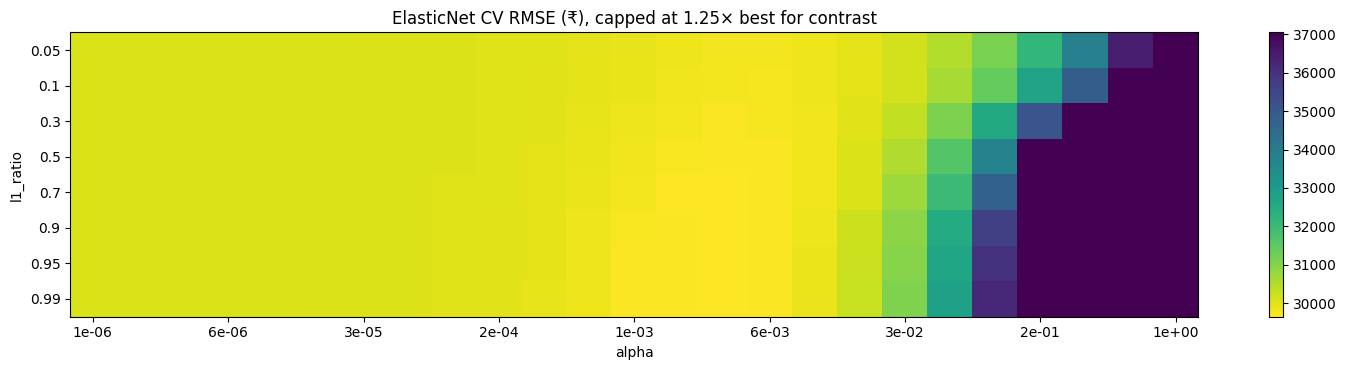

In [8]:
L1_RATIOS = [0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
gs_en, cv_en, t_en = search(ElasticNet(max_iter=100_000, random_state=RANDOM_STATE),
                            {"alpha": np.logspace(-6, 0, 25), "l1_ratio": L1_RATIOS})
best_en = {k.split("__")[-1]: v for k, v in gs_en.best_params_.items()}
print(f"ElasticNet: best {best_en} | CV RMSE ₹{-gs_en.best_score_:,.0f} | search {t_en:.1f}s ({len(cv_en)} candidates)")
heat = cv_en.pivot_table(index="l1_ratio", columns="alpha", values="cv_rmse")
fig, ax = plt.subplots(figsize=(15, 3.8))
im = ax.imshow(np.minimum(heat.values, heat.values.min() * 1.25), aspect="auto", cmap="viridis_r")
ax.set_yticks(range(len(heat.index)), heat.index); ax.set_xticks(range(0, len(heat.columns), 3),
              [f"{a:.0e}" for a in heat.columns[::3]])
ax.set_xlabel("alpha"); ax.set_ylabel("l1_ratio"); ax.set_title("ElasticNet CV RMSE (₹), capped at 1.25× best for contrast")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 5. Under/overfitting along the regularization path (train vs CV error)

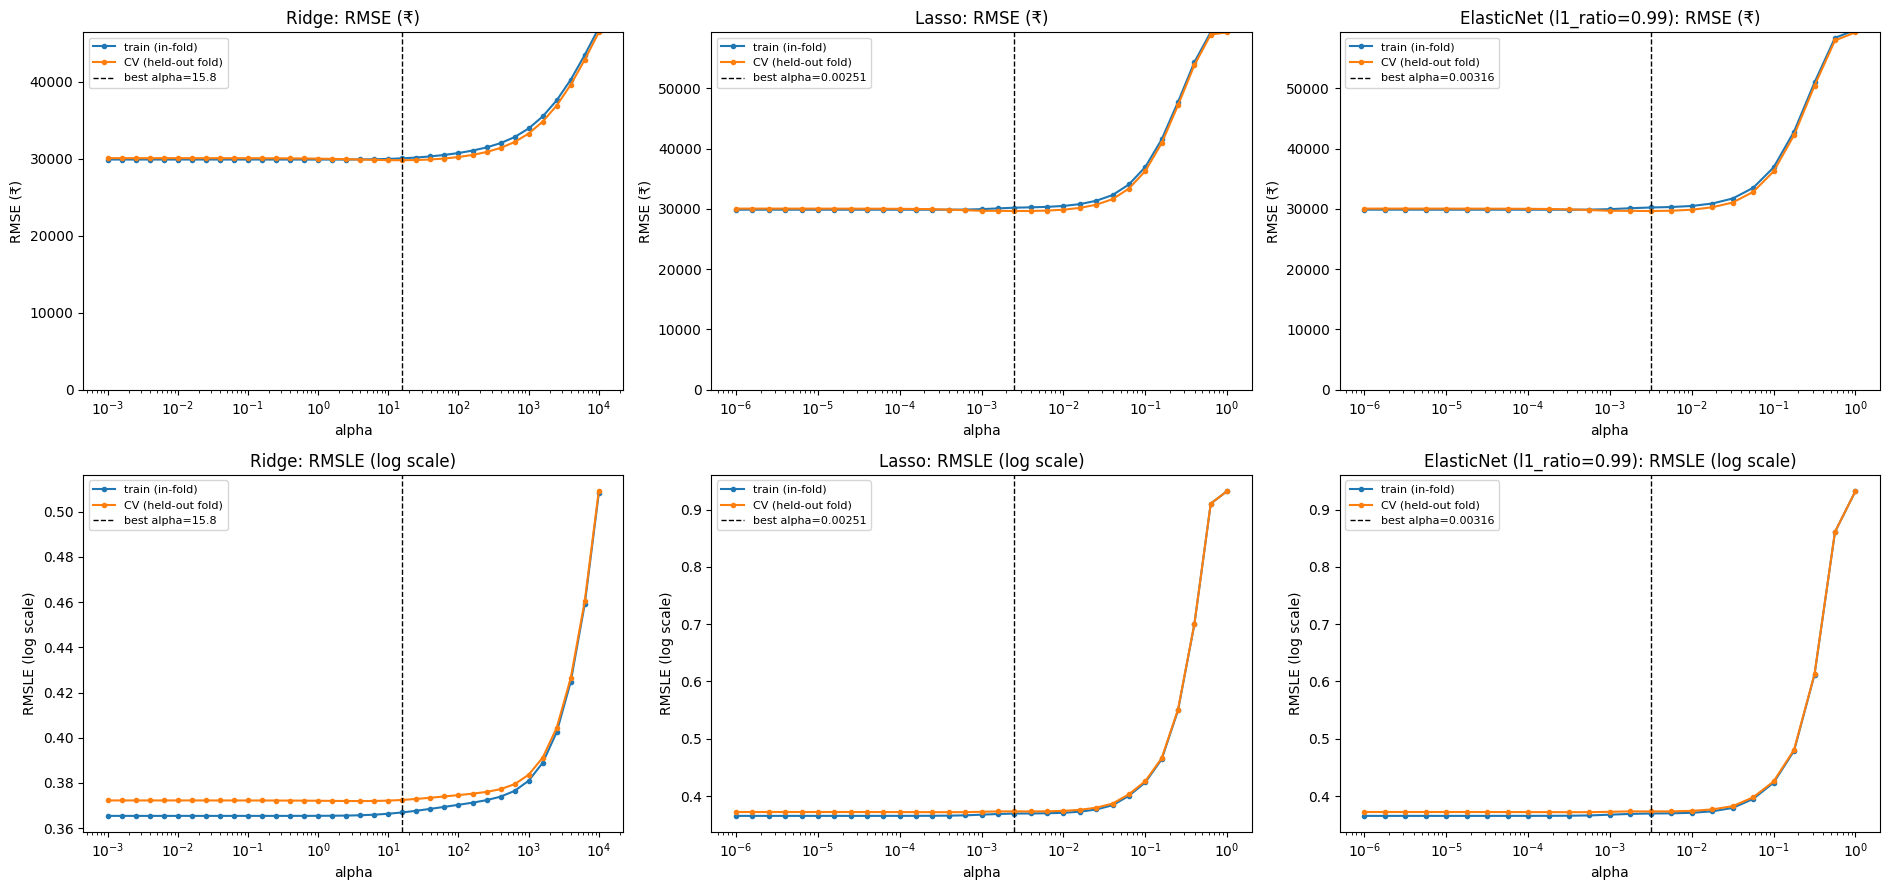

Left of the best alpha, the train/CV gap shows variance (overfitting); right of it, both errors rise together (underfitting).


In [9]:
en_best_l1 = best_en["l1_ratio"]
cv_en_line = cv_en[np.isclose(cv_en["l1_ratio"], en_best_l1)].sort_values("alpha")
fig, ax = plt.subplots(2, 3, figsize=(19, 9))
for j, (name, cvr, best) in enumerate([("Ridge", cv_ridge, best_ridge), ("Lasso", cv_lasso, best_lasso),
                                       (f"ElasticNet (l1_ratio={en_best_l1})", cv_en_line, best_en["alpha"])]):
    for i, (m, lab) in enumerate([("rmse", "RMSE (₹)"), ("rmsle", "RMSLE (log scale)")]):
        a = ax[i, j]
        a.plot(cvr["alpha"], cvr[f"train_{m}"], "o-", ms=3, label="train (in-fold)")
        a.plot(cvr["alpha"], cvr[f"cv_{m}"], "o-", ms=3, label="CV (held-out fold)")
        a.axvline(best, color="k", ls="--", lw=1, label=f"best alpha={best:.3g}")
        a.set_xscale("log"); a.set_xlabel("alpha"); a.set_ylabel(lab); a.set_title(f"{name}: {lab}")
        if m == "rmse":
            a.set_ylim(0, min(cvr["cv_rmse"].max(), 3 * cvr["cv_rmse"].min()))
        a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Left of the best alpha, the train/CV gap shows variance (overfitting); right of it, both errors rise together (underfitting).")

## 6. Coefficient shrinkage and sparsity (full train fit at each alpha; standardised coefficients, log-rent scale)

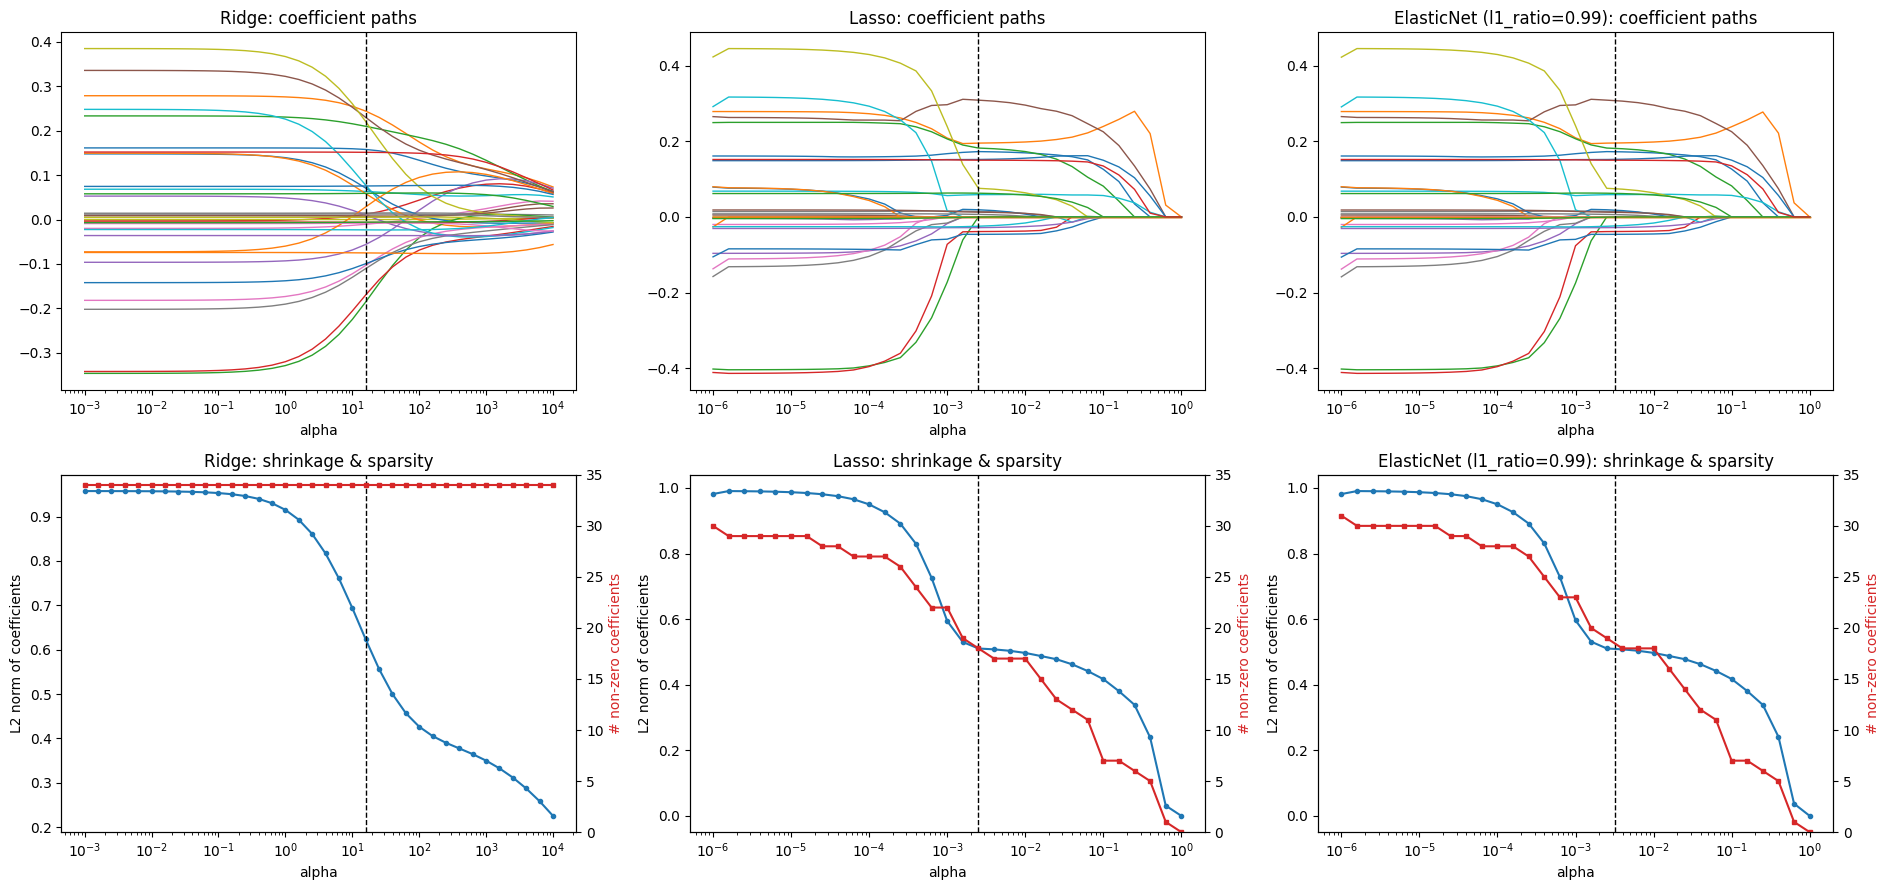

In [10]:
def coef_path(est_factory, alphas):
    rows = []
    for a in alphas:
        m = make_model(est_factory(a)).fit(X_train, y_train)
        rows.append(m.regressor_.named_steps["model"].coef_)
    return pd.DataFrame(rows, index=alphas, columns=feature_names)

paths = {"Ridge": coef_path(lambda a: Ridge(alpha=a), ALPHAS_RIDGE),
         "Lasso": coef_path(lambda a: Lasso(alpha=a, max_iter=100_000, random_state=RANDOM_STATE), ALPHAS_L1),
         f"ElasticNet (l1_ratio={en_best_l1})": coef_path(
             lambda a: ElasticNet(alpha=a, l1_ratio=en_best_l1, max_iter=100_000, random_state=RANDOM_STATE), ALPHAS_L1)}
bests = [best_ridge, best_lasso, best_en["alpha"]]
fig, ax = plt.subplots(2, 3, figsize=(19, 9))
for j, ((name, P), b) in enumerate(zip(paths.items(), bests)):
    ax[0, j].plot(P.index, P.values, lw=1); ax[0, j].set_xscale("log"); ax[0, j].axvline(b, color="k", ls="--", lw=1)
    ax[0, j].set_title(f"{name}: coefficient paths"); ax[0, j].set_xlabel("alpha")
    ax[1, j].plot(P.index, np.linalg.norm(P.values, axis=1), "o-", ms=3, label="‖β‖₂")
    ax2 = ax[1, j].twinx(); ax2.plot(P.index, (np.abs(P.values) > 1e-10).sum(axis=1), "s-", ms=3, color="tab:red", label="# non-zero")
    ax2.set_ylabel("# non-zero coefficients", color="tab:red"); ax2.set_ylim(0, len(feature_names) + 1)
    ax[1, j].set_xscale("log"); ax[1, j].axvline(b, color="k", ls="--", lw=1); ax[1, j].set_xlabel("alpha")
    ax[1, j].set_ylabel("L2 norm of coefficients"); ax[1, j].set_title(f"{name}: shrinkage & sparsity")
plt.tight_layout(); plt.show()

## 7. Tuned vs default vs OLS: train / CV / validation (₹)

In [11]:
def evaluate(name, model, params):
    t0 = time.perf_counter(); model.fit(X_train, y_train); tt = time.perf_counter() - t0
    cvr = cross_validate(clone(model), X_train, y_train, cv=cv, scoring=SCORING)
    pt, pv = model.predict(X_train), model.predict(X_val)
    coef = model.regressor_.named_steps["model"].coef_
    row = {"model": name, "params": params,
           "Train RMSE": rmse(y_train, pt), "CV RMSE": -cvr["test_rmse"].mean(), "CV RMSE sd": cvr["test_rmse"].std(),
           "CV MAE": -cvr["test_mae"].mean(), "CV R²": cvr["test_r2"].mean(),
           "Val MAE": mean_absolute_error(y_val, pv), "Val MSE": mean_squared_error(y_val, pv), "Val RMSE": rmse(y_val, pv),
           "Val R²": r2_score(y_val, pv), "Val RMSLE": rmsle(y_val, pv),
           "non-zero coefs": int((np.abs(coef) > 1e-10).sum()), "‖β‖₂": float(np.linalg.norm(coef)), "Train time (s)": tt}
    if EVALUATE_TEST:
        ps = model.predict(X_test); row.update({"Test RMSE": rmse(y_test, ps), "Test MAE": mean_absolute_error(y_test, ps),
                                                "Test R²": r2_score(y_test, ps)})
    return row, model, pv

specs = [("OLS (reference)", LinearRegression(), "—"),
         ("Ridge default", Ridge(alpha=1.0), "alpha=1"),
         ("Ridge tuned", Ridge(alpha=best_ridge), f"alpha={best_ridge:.4g}"),
         ("Lasso default", Lasso(alpha=1.0, max_iter=100_000, random_state=RANDOM_STATE), "alpha=1"),
         ("Lasso tuned", Lasso(alpha=best_lasso, max_iter=100_000, random_state=RANDOM_STATE), f"alpha={best_lasso:.4g}"),
         ("ElasticNet default", ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=100_000, random_state=RANDOM_STATE), "alpha=1, l1=0.5"),
         ("ElasticNet tuned", ElasticNet(alpha=best_en["alpha"], l1_ratio=best_en["l1_ratio"], max_iter=100_000,
                                         random_state=RANDOM_STATE), f"alpha={best_en['alpha']:.4g}, l1={best_en['l1_ratio']}")]
rows, fitted, val_pred = [], {}, {}
for name, est, params in specs:
    r, m, pv = evaluate(name, make_model(est), params); rows.append(r); fitted[name] = m; val_pred[name] = pv
summary = pd.DataFrame(rows).set_index("model")
summary["Train−CV gap"] = summary["CV RMSE"] - summary["Train RMSE"]
fmt = {c: "₹{:,.0f}" for c in ["Train RMSE", "CV RMSE", "CV RMSE sd", "CV MAE", "Val MAE", "Val RMSE", "Train−CV gap"]}
fmt.update({"Val MSE": "{:.4g}", "CV R²": "{:.4f}", "Val R²": "{:.4f}", "Val RMSLE": "{:.4f}", "‖β‖₂": "{:.3f}", "Train time (s)": "{:.3f}"})
display(summary.style.format(fmt))

,params,Train RMSE,CV RMSE,CV RMSE sd,CV MAE,CV R²,Val MAE,Val MSE,Val RMSE,Val R²,Val RMSLE,non-zero coefs,‖β‖₂,Train time (s),Train−CV gap
model,,,,,,,,,,,,,,,
OLS (reference),—,"₹30,041","₹30,056","₹6,850","₹10,676",0.7286,"₹13,596",2.687e+09,"₹51,834",0.4879,0.4399,34,0.957,0.022,₹15
Ridge default,alpha=1,"₹30,035","₹29,992","₹6,947","₹10,668",0.7299,"₹13,589",2.698e+09,"₹51,941",0.4858,0.4399,34,0.915,0.003,₹-43
Ridge tuned,alpha=15.85,"₹30,142","₹29,787","₹7,507","₹10,639",0.7339,"₹13,533",2.784e+09,"₹52,760",0.4695,0.4406,34,0.623,0.002,₹-355
Lasso default,alpha=1,"₹59,755","₹59,321","₹7,248","₹24,373",-0.0653,"₹25,798",5.506e+09,"₹74,205",-0.0494,0.9458,0,0.000,0.003,₹-434
Lasso tuned,alpha=0.002512,"₹30,309","₹29,651","₹7,508","₹10,657",0.7364,"₹13,545",2.797e+09,"₹52,888",0.4669,0.4407,18,0.510,0.004,₹-658
ElasticNet default,"alpha=1, l1=0.5","₹57,914","₹57,448","₹7,490","₹22,751",0.0027,"₹24,223",5.288e+09,"₹72,717",-0.0078,0.8472,6,0.086,0.003,₹-466
ElasticNet tuned,"alpha=0.003162, l1=0.99","₹30,328","₹29,645","₹7,486","₹10,655",0.7365,"₹13,541",2.801e+09,"₹52,929",0.4661,0.4407,18,0.509,0.004,₹-683


In [12]:
# Which coefficients did Lasso / ElasticNet drop, and how much did Ridge shrink vs OLS?
coefs = pd.DataFrame({n: fitted[n].regressor_.named_steps["model"].coef_
                      for n in ["OLS (reference)", "Ridge tuned", "Lasso tuned", "ElasticNet tuned"]}, index=feature_names)
print("Zeroed by tuned Lasso     :", coefs.index[np.abs(coefs["Lasso tuned"]) <= 1e-10].tolist())
print("Zeroed by tuned ElasticNet:", coefs.index[np.abs(coefs["ElasticNet tuned"]) <= 1e-10].tolist())
display(coefs.reindex(coefs["Ridge tuned"].abs().sort_values(ascending=False).index).round(4).head(15))

Zeroed by tuned Lasso     : ['log_bhk', 'log_bath', 'current_floor', 'total_floors', 'is_basement', 'logsize_x_Chennai', 'logsize_x_Delhi', 'logsize_x_Kolkata', 'City_Bangalore', 'City_Chennai', 'City_Hyderabad', 'City_Mumbai', 'Furnishing_Status_Semi_Furnished', 'Area_Type_Super_Area', 'Tenant_Preferred_Bachelors_Family', 'Point_of_Contact_Contact_Owner']
Zeroed by tuned ElasticNet: ['log_bhk', 'log_bath', 'current_floor', 'total_floors', 'is_basement', 'logsize_x_Chennai', 'logsize_x_Delhi', 'logsize_x_Kolkata', 'City_Bangalore', 'City_Chennai', 'City_Hyderabad', 'City_Mumbai', 'Furnishing_Status_Semi_Furnished', 'Tenant_Preferred_Bachelors_Family', 'Point_of_Contact_Contact_Owner', 'Point_of_Contact_infrequent_sklearn']


,OLS (reference),Ridge tuned,Lasso tuned,ElasticNet tuned
Bathroom,0.2785,0.2439,0.1950,0.1953
logsize_x_Mumbai,0.3354,0.2298,0.3085,0.3074
City_Delhi,0.3845,0.2205,0.0757,0.0747
log_size,0.2331,0.2097,0.1820,0.1812
logsize_x_Delhi,-0.3462,-0.1855,-0.0000,-0.0000
logsize_x_Hyderabad,-0.3420,-0.1698,-0.0386,-0.0386
BHK,0.1611,0.1576,0.1726,0.1723
locality_target_enc,0.1518,0.1512,0.1500,0.1499
City_Chennai,-0.2020,-0.1105,-0.0000,-0.0000
City_Bangalore,-0.1819,-0.1034,0.0000,0.0000


In [13]:
# Validation diagnostic (comparison only): how much of each model's val squared error comes from its single worst row?
diag = []
for n, pv in val_pred.items():
    e = y_val.to_numpy() - pv; se = e ** 2; k = np.argmax(se)
    diag.append({"model": n, "Val RMSE": np.sqrt(se.mean()), "worst-row share of SSE": se[k] / se.sum(),
                 "Val RMSE without worst row": np.sqrt(np.delete(se, k).mean()), "worst row actual ₹": int(y_val.iloc[k])})
display(pd.DataFrame(diag).set_index("model").round(3))

,Val RMSE,worst-row share of SSE,Val RMSE without worst row,worst row actual ₹
model,,,,
OLS (reference),51834.123,0.446,38611.278,1200000
Ridge default,51940.828,0.448,38617.795,1200000
Ridge tuned,52759.743,0.462,38730.745,1200000
Lasso default,74205.066,0.356,59593.003,1200000
Lasso tuned,52887.929,0.465,38720.154,1200000
ElasticNet default,72717.360,0.366,57948.340,1200000
ElasticNet tuned,52928.542,0.465,38741.982,1200000


In [14]:
# Save outputs
summary.reset_index().to_csv("outputs/phase7_summary.csv", index=False)
pd.concat({"ridge": cv_ridge, "lasso": cv_lasso}, names=["model"]).to_csv("outputs/phase7_cv_path_ridge_lasso.csv")
cv_en.to_csv("outputs/phase7_cv_grid_elasticnet.csv", index=False)
for n in ["Ridge tuned", "Lasso tuned", "ElasticNet tuned"]:
    pv = val_pred[n]; key = n.split()[0].lower()
    pd.DataFrame({"row_id": X_val.index, "split": "val", "actual_rent": y_val.to_numpy(), "predicted_rent": pv,
                  "residual": y_val.to_numpy() - pv}).to_csv(f"outputs/predictions_phase7_{key}_tuned.csv", index=False)
best_params = {"ridge": {"alpha": float(best_ridge)}, "lasso": {"alpha": float(best_lasso)},
               "elasticnet": {"alpha": float(best_en["alpha"]), "l1_ratio": float(best_en["l1_ratio"])}}
with open("outputs/phase7_best_params.json", "w") as f:
    json.dump({"reference_id": EXPECTED_REFERENCE_ID, "selection": "min 5-fold CV RMSE (₹) on train", **best_params}, f, indent=2)
print(json.dumps(best_params, indent=2))

{
  "ridge": {
    "alpha": 15.848931924611142
  },
  "lasso": {
    "alpha": 0.002511886431509582
  },
  "elasticnet": {
    "alpha": 0.0031622776601683794,
    "l1_ratio": 0.99
  }
}



## 8. Phase-7 decisions

Alpha was chosen **only** by 5-fold CV RMSE (₹) on train. Validation is shown for comparison.

| Model | Tuned params | CV RMSE | CV MAE | CV R² | Val MAE | Val RMSE | Val R² | Non-zero coefs | ‖β‖₂ |
|---|---|---|---|---|---|---|---|---|---|
| OLS (reference) | — | ₹30,056 | ₹10,676 | 0.7286 | ₹13,596 | ₹51,834 | 0.488 | 34/34 | 0.957 |
| **Ridge** | α = 15.85 | ₹29,787 | ₹10,639 | 0.7339 | ₹13,533 | ₹52,760 | 0.470 | 34/34 | 0.623 |
| **Lasso** | α = 0.00251 | ₹29,651 | ₹10,657 | 0.7364 | ₹13,545 | ₹52,888 | 0.467 | **18/34** | 0.510 |
| **ElasticNet** | α = 0.00316, l1_ratio = 0.99 | **₹29,645** | ₹10,655 | **0.7365** | ₹13,541 | ₹52,929 | 0.466 | 18/34 | 0.509 |
| Lasso / EN at default α=1 | — | ₹59,321 / ₹57,448 | — | ≈ 0 | — | ₹74k / ₹73k | ≈ 0 | 0 / 6 | ≈ 0 |

### Findings
1. **The defaults were badly mis-scaled, not the models.** On a log-rent target (variance ≈ 0.9) with standardised features, α=1 makes the L1 penalty dominate: Lasso keeps 0 coefficients and ElasticNet keeps 6. Tuning brings α down by about 400x, and both recover to OLS-level accuracy.
2. **The linear family is bias-limited, not variance-limited.** OLS train RMSE (₹30,041) ≈ its CV RMSE (₹30,056), and along every path the train and CV curves stay together until α gets large enough to underfit. With 3,313 rows and 34 features there is little variance to remove.
3. **Regularization buys ≤1.4% CV RMSE** (₹30,056 → ₹29,645), a gain about 18x smaller than the fold-to-fold CV sd (≈₹7,500). The three tuned models are **statistically indistinguishable**: their CV RMSE spans ₹142, and across l1_ratio ElasticNet's best CV RMSE only moves from ₹29,645 to ₹29,772.
4. **Shrinkage and sparsity:** Ridge shrinks ‖β‖₂ by 35% but keeps all 34 coefficients. Lasso zeroes 16. The zeroed ones are redundant encodings: the City dummies (their effect is carried by the `logsize_x_City` interactions), `log_bhk`/`log_bath` (duplicates of `BHK`/`Bathroom`), the floor variables, and the second level of two-level one-hots. Surviving signal: `Bathroom`, `logsize_x_Mumbai`, `log_size`, `BHK`, `locality_target_enc` (≈0.15, stable across all models), Point of Contact = Agent.
5. **ElasticNet chose l1_ratio = 0.99, the edge of the grid.** That is not a missed optimum: l1_ratio → 1 *is* Lasso, which was searched separately and lands within ₹6 of it. **ElasticNet collapses to Lasso here.**
6. **Validation agrees on MAE and disagrees mildly on RMSE.** Tuned MAE is slightly better than OLS (₹13.53–13.55k vs ₹13.60k). Tuned RMSE is about 2% worse, because the genuine ₹12,00,000 validation row carries about 46% of every model's validation SSE. Without that single row, all tuned models and OLS sit at ₹38.6–38.7k. Validation does not justify overriding the CV choice.

### Decisions
* **Linear representative for Phase 9: Lasso (α = 0.00251).** It ties for best CV RMSE and R², uses half the features (18/34), and is more interpretable than ElasticNet, which collapses to it anyway. **Ridge (α = 15.85)** is kept as the dense-model reference. Both are fully tuned here and need **no Phase-8 search**.
* **The linear ceiling is about ₹29.6k CV RMSE / ₹10.65k CV MAE / ₹13.5k val MAE.** Phase 6's untuned Gradient Boosting (CV RMSE ₹28.0k) and Random Forest (val MAE ₹11.7k) already beat it. Remaining error comes from bias (non-linear and interaction structure), not variance, so **Phase 8 should tune the tree ensembles** (Random Forest, Gradient Boosting, plus XGBoost/LightGBM/CatBoost once they have run in Colab).
* Best params are saved to `outputs/phase7_best_params.json` for Phase 9. CV paths and the grid are saved as CSV.
